# Numerical Linear Algebra — Notebook 5: Eigenvalues

**Topics covered:** Eigenvalue Problems and Algorithms · Hessenberg/Tridiagonal Reduction · Rayleigh Quotient · QR Algorithm · Power/Inverse Iteration and SVD Connection

**Prerequisites:** Notebooks 1–4.


In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})


---
## 1. Eigenvalue Problems and Algorithms

### Motivation

Eigenvalues appear in stability analysis of dynamical systems, principal component analysis,
graph theory, and the convergence analysis of iterative solvers.
Unlike linear systems, eigenvalue problems are **inherently nonlinear** (eigenvalues are roots of a polynomial),
so all practical algorithms are iterative.

### Definitions

A scalar $\lambda \in \mathbb{C}$ and nonzero $x \in \mathbb{C}^n$ satisfying

$$Ax = \lambda x$$

are an **eigenvalue** and **eigenvector** of $A \in \mathbb{R}^{n \times n}$.
The set of all eigenvalues is the **spectrum** $\Lambda(A)$.

The eigenvalues are the roots of the **characteristic polynomial**:

$$p(\lambda) = \det(A - \lambda I),$$

a degree-$n$ polynomial. By the Abel-Ruffini theorem, no closed-form formula exists for $n \ge 5$.
All eigenvalue algorithms are therefore iterative.

### Schur Decomposition

Every $A \in \mathbb{R}^{n \times n}$ satisfies:

$$A = QTQ^*, \quad Q \text{ unitary},\quad T \text{ upper triangular.}$$

The eigenvalues appear on the diagonal of $T$. For real $A$, the **real Schur form** has
$1 \times 1$ (real eigenvalue) and $2 \times 2$ (complex conjugate pair) blocks on the diagonal.

### Symmetric Case

If $A = A^{\top}$, then $A = Q\Lambda Q^{\top}$ with $Q$ orthogonal and $\Lambda$ real diagonal.
All eigenvalues are real; eigenvectors corresponding to distinct eigenvalues are orthogonal.


In [2]:
# Basic eigenvalue computations: symmetric vs nonsymmetric
np.random.seed(11)
n = 5

# Symmetric positive definite matrix
B = np.random.randn(n, n)
A_sym = B.T @ B + np.eye(n)

# General nonsymmetric matrix
A_gen = np.random.randn(n, n)

print("=== Symmetric matrix ===")
eigvals_s, eigvecs_s = np.linalg.eigh(A_sym)   # eigh for symmetric: real, sorted
print(f"  Eigenvalues (all real): {eigvals_s}")
print(f"  Eigenvectors orthogonal: ||Q^T Q - I||_F = "
      f"{np.linalg.norm(eigvecs_s.T @ eigvecs_s - np.eye(n), 'fro'):.2e}")
print(f"  Decomposition error:    ||A - Q Lambda Q^T||_F = "
      f"{np.linalg.norm(A_sym - eigvecs_s @ np.diag(eigvals_s) @ eigvecs_s.T, 'fro'):.2e}")

print("\n=== Nonsymmetric matrix ===")
eigvals_g, eigvecs_g = np.linalg.eig(A_gen)    # eig for general: may be complex
print(f"  Eigenvalues: {eigvals_g}")
print(f"  Some eigenvalues complex: {np.any(np.abs(eigvals_g.imag) > 1e-10)}")
print("  Residuals max ||A v_i - lambda_i v_i||_2:")
for i in range(n):
    res = np.linalg.norm(A_gen @ eigvecs_g[:, i] - eigvals_g[i] * eigvecs_g[:, i])
    print(f"    i={i}: {res:.2e}")


=== Symmetric matrix ===
  Eigenvalues (all real): [ 1.00665992  3.08131344  3.44531525  7.4012442  15.15534768]
  Eigenvectors orthogonal: ||Q^T Q - I||_F = 1.15e-15
  Decomposition error:    ||A - Q Lambda Q^T||_F = 7.25e-15

=== Nonsymmetric matrix ===
  Eigenvalues: [-1.02329637+1.01471277j -1.02329637-1.01471277j  1.12953499+0.12490138j
  1.12953499-0.12490138j -0.31662487+0.j        ]
  Some eigenvalues complex: True
  Residuals max ||A v_i - lambda_i v_i||_2:
    i=0: 2.02e-15
    i=1: 2.02e-15
    i=2: 1.19e-15
    i=3: 1.19e-15
    i=4: 1.28e-15


Schur decomposition of nonsymmetric A:
  ||A - Q T Q^T||_F = 4.40e-15
  Eigenvalues from T diagonal: [-1.02329637 -1.02329637 -0.31662487  1.12953499  1.12953499]
  Eigenvalues from np.linalg.eig: [-1.02329637-1.01471277j -1.02329637+1.01471277j -0.31662487+0.j
  1.12953499-0.12490138j  1.12953499+0.12490138j]


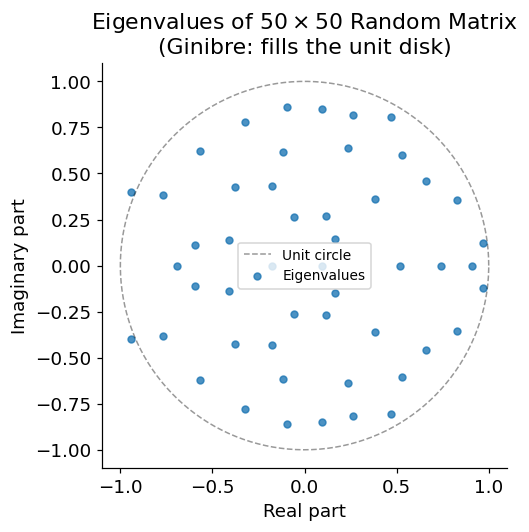

In [3]:
# Schur decomposition via scipy
T_s, Q_s = la.schur(A_gen)
print("Schur decomposition of nonsymmetric A:")
print(f"  ||A - Q T Q^T||_F = {np.linalg.norm(A_gen - Q_s @ T_s @ Q_s.T, 'fro'):.2e}")
print(f"  Eigenvalues from T diagonal: {np.sort(np.diag(T_s))}")
print(f"  Eigenvalues from np.linalg.eig: {np.sort(np.linalg.eigvals(A_gen))}")

# Visualize eigenvalues of random matrix in complex plane
n_vis = 50
A_large = np.random.randn(n_vis, n_vis) / np.sqrt(n_vis)  # normalized random matrix
eigs = np.linalg.eigvals(A_large)

fig, ax = plt.subplots(figsize=(5, 5))
theta_c = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta_c), np.sin(theta_c), 'k--', lw=1, alpha=0.4, label='Unit circle')
ax.scatter(eigs.real, eigs.imag, s=20, alpha=0.8, label='Eigenvalues')
ax.set_aspect('equal')
ax.set_xlabel('Real part')
ax.set_ylabel('Imaginary part')
title = (r'Eigenvalues of $50\times50$ Random Matrix' + '\n' +
         r'(Ginibre: fills the unit disk)')
ax.set_title(title)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## 2. Reduction to Hessenberg or Tridiagonal Form

### Motivation

Before applying iterative eigenvalue algorithms, reduce $A$ to **Hessenberg form** (upper Hessenberg for general $A$,
tridiagonal for symmetric $A$) via an orthogonal similarity transformation:

$$Q^{\top}AQ = H.$$

This is a **one-time $O(n^3)$ investment** that pays off because each subsequent QR iteration costs $O(n^2)$
on a Hessenberg matrix versus $O(n^3)$ on a general matrix.

### Upper Hessenberg Form

$H \in \mathbb{R}^{n \times n}$ is **upper Hessenberg** if $h_{ij} = 0$ for $i > j + 1$.

$$H = \begin{pmatrix}
* & * & * & * \\
* & * & * & * \\
0 & * & * & * \\
0 & 0 & * & *
\end{pmatrix}$$

### Tridiagonal Form (Symmetric Case)

If $A = A^{\top}$, then $H = Q^{\top}AQ$ is symmetric Hessenberg, i.e., **tridiagonal**.

### Algorithm

Apply $n-2$ Householder reflectors acting on columns $2, 3, \ldots, n-1$:

- $H^{(k)}$ zeros out entries below the first subdiagonal in column $k$.
- Applying from both sides (left and right) preserves the similarity transformation.

**Cost:** Approximately $\frac{10}{3}n^3$ flops for a general matrix; $\frac{4}{3}n^3$ for symmetric.

### Why Hessenberg Form is Preserved by QR

If $H$ is upper Hessenberg and $H = QR$ is the QR factorization,
then $H' = RQ$ is also upper Hessenberg. This means Hessenberg form is an invariant of the QR iteration.


Hessenberg reduction: Q^T A Q = H
  ||Q^T A Q - H||_F = 1.27e-15
  ||Q^T Q - I||_F   = 6.59e-16

  Max entry more than 1 below subdiagonal: 0.00e+00


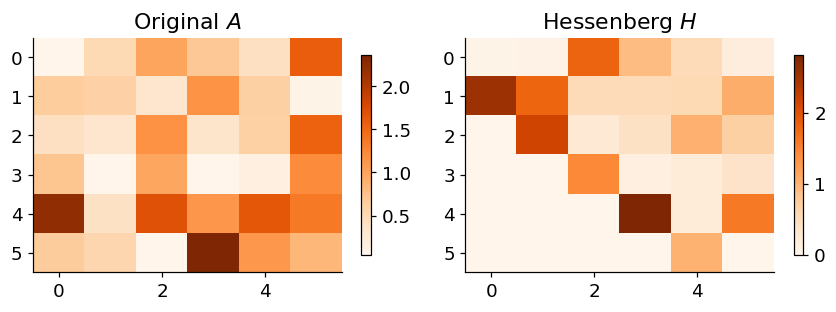

In [4]:
# Hessenberg reduction
np.random.seed(4)
n = 6
A_h = np.random.randn(n, n)

H, Q_h = la.hessenberg(A_h, calc_q=True)

print("Hessenberg reduction: Q^T A Q = H")
print(f"  ||Q^T A Q - H||_F = {np.linalg.norm(Q_h.T @ A_h @ Q_h - H, 'fro'):.2e}")
print(f"  ||Q^T Q - I||_F   = {np.linalg.norm(Q_h.T @ Q_h - np.eye(n), 'fro'):.2e}")

# Maximum entry more than 1 below the subdiagonal (should be ~0)
max_below = max(abs(H[i, j]) for i in range(n) for j in range(n) if i > j+1)
print(f"\n  Max entry more than 1 below subdiagonal: {max_below:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, M, title in zip(axes, [A_h, H], ['Original $A$', 'Hessenberg $H$']):
    im = ax.imshow(np.abs(M), cmap='Oranges', aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()


In [5]:
# Symmetric case: tridiagonal form
np.random.seed(5)
n_sym = 7
B_sym = np.random.randn(n_sym, n_sym)
A_sym2 = B_sym.T @ B_sym + np.eye(n_sym)

# scipy tridiagonalize via Householder (eigh_tridiagonal is for already tridiagonal matrices)
# Use scipy's hessenberg which gives tridiagonal for symmetric input via the Lanczos reduction
T_tri, Q_tri = la.hessenberg(A_sym2, calc_q=True)

print("Tridiagonalization of symmetric matrix: Q^T A Q = T")
print(f"  ||Q^T A Q - T||_F = {np.linalg.norm(Q_tri.T @ A_sym2 @ Q_tri - T_tri, 'fro'):.2e}")
print(f"  T is symmetric:   ||T - T^T||_F = {np.linalg.norm(T_tri - T_tri.T, 'fro'):.2e}")

# For a symmetric matrix, hessenberg should give a tridiagonal result
max_off = max(abs(T_tri[i, j]) for i in range(n_sym) for j in range(n_sym)
              if abs(i - j) > 1)
print(f"  Max off-tridiagonal entry: {max_off:.2e}  (should be ~eps_mach)")


Tridiagonalization of symmetric matrix: Q^T A Q = T
  ||Q^T A Q - T||_F = 7.40e-15
  T is symmetric:   ||T - T^T||_F = 5.88e-15
  Max off-tridiagonal entry: 2.02e-15  (should be ~eps_mach)


In [6]:
# Computational benefit: QR step cost on full vs Hessenberg matrix
n_cost = 300
A_full = np.random.randn(n_cost, n_cost)
H_cost, _ = la.hessenberg(A_full, calc_q=True)

import time

# QR step on full matrix
t0 = time.perf_counter()
for _ in range(20):
    Q_f, R_f = np.linalg.qr(A_full)
t_full = (time.perf_counter() - t0) / 20

# QR step on Hessenberg matrix (NumPy doesn't exploit structure, but conceptually O(n^2))
t0 = time.perf_counter()
for _ in range(20):
    Q_hc, R_hc = np.linalg.qr(H_cost)
t_hess = (time.perf_counter() - t0) / 20

print(f"QR step timing (n={n_cost}):")
print(f"  Full matrix:      {t_full*1000:.2f} ms")
print(f"  Hessenberg matrix:{t_hess*1000:.2f} ms")
print(f"  Note: NumPy does not exploit Hessenberg structure; structured implementations")
print(f"  reduce each QR step from O(n^3) to O(n^2) using Givens rotations.")


QR step timing (n=300):
  Full matrix:      68.03 ms
  Hessenberg matrix:71.20 ms
  Note: NumPy does not exploit Hessenberg structure; structured implementations
  reduce each QR step from O(n^3) to O(n^2) using Givens rotations.


---
## 3. Rayleigh Quotient

### Definition

The **Rayleigh quotient** of $A \in \mathbb{R}^{n \times n}$ at $x \neq 0$ is:

$$r(x) = \frac{x^{\top}Ax}{x^{\top}x}.$$

### Key Properties (Symmetric $A$)

- If $x = q_i$ (eigenvector), then $r(q_i) = \lambda_i$.
- $\lambda_{\min}(A) \le r(x) \le \lambda_{\max}(A)$ for all $x \neq 0$.
- $\nabla_x r(x) = 0$ at eigenvectors (Rayleigh quotient is stationary at eigenvectors).
- **Quadratic convergence:** If $x = q_i + O(\varepsilon)$, then $r(x) = \lambda_i + O(\varepsilon^2)$.
  The Rayleigh quotient approximates the eigenvalue quadratically better than the eigenvector approximation.

### Rayleigh Quotient Iteration

At each step, set the shift $\mu_k = r(x_k)$ and solve $(A - \mu_k I)y = x_k$, then normalize:

$$x_{k+1} = \frac{y}{\|y\|_2}.$$

This is inverse iteration with a Rayleigh quotient shift.
Convergence to an eigenpair is **cubically fast** once close to an eigenvalue.


True smallest eigenvalue: 1.0000426356


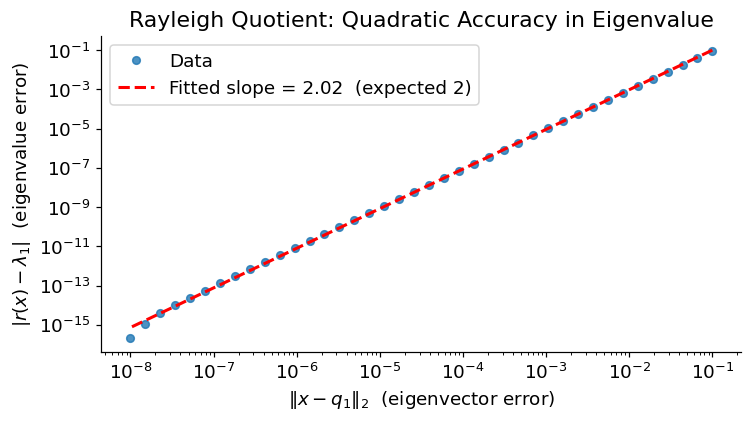

Observed log-log slope: 2.020  (theory predicts 2.0)


In [7]:
# Rayleigh quotient: quadratic accuracy in eigenvalue approximation
np.random.seed(6)
n_rq = 6
B_rq = np.random.randn(n_rq, n_rq)
A_rq = B_rq.T @ B_rq + np.eye(n_rq)

eigvals_rq, eigvecs_rq = np.linalg.eigh(A_rq)
lam_true = eigvals_rq[0]      # smallest eigenvalue
q_true   = eigvecs_rq[:, 0]   # corresponding eigenvector

print(f"True smallest eigenvalue: {lam_true:.10f}")

# Perturb the eigenvector by epsilon and measure eigenvalue error
epsilons = np.logspace(-1, -8, 40)
eig_errs, vec_errs = [], []

for eps in epsilons:
    np.random.seed(0)
    noise = np.random.randn(n_rq)
    noise -= (q_true @ noise) * q_true   # orthogonalize against q_true
    norm_n = np.linalg.norm(noise)
    if norm_n < 1e-14:
        continue
    noise /= norm_n
    x_pert = q_true + eps * noise
    x_pert /= np.linalg.norm(x_pert)

    rq  = x_pert @ A_rq @ x_pert   # Rayleigh quotient
    ve  = np.linalg.norm(x_pert - q_true)
    ee  = abs(rq - lam_true)
    if ve > 0 and ee > 0:           # only keep strictly positive pairs for log-fit
        vec_errs.append(ve)
        eig_errs.append(ee)

# Log-log fit to verify quadratic convergence slope
log_v = np.log(vec_errs)
log_e = np.log(eig_errs)
coeffs = np.polyfit(log_v, log_e, 1)
slope  = coeffs[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(vec_errs, eig_errs, 'o', ms=5, alpha=0.8, label='Data')
ax.loglog(vec_errs, np.exp(np.polyval(coeffs, log_v)),
          'r--', lw=2, label=f'Fitted slope = {slope:.2f}  (expected 2)')
ax.set_xlabel(r'$\|x - q_1\|_2$  (eigenvector error)')
ax.set_ylabel(r'$|r(x) - \lambda_1|$  (eigenvalue error)')
ax.set_title('Rayleigh Quotient: Quadratic Accuracy in Eigenvalue')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observed log-log slope: {slope:.3f}  (theory predicts 2.0)")


Rayleigh Quotient Iteration on 8x8 symmetric matrix:
  Converged eigenvalue: 10.088566361371
  Nearest true eigenvalue: 10.088566361371


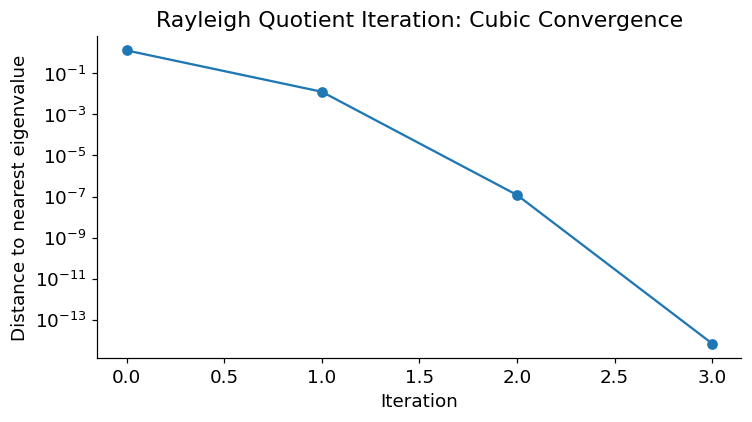

In [8]:
# Rayleigh Quotient Iteration: cubic convergence
def rayleigh_quotient_iter(A, x0, max_iter=30, tol=1e-14):
    'Rayleigh Quotient Iteration for symmetric A.'
    n = A.shape[0]
    x = x0 / np.linalg.norm(x0)
    history = []
    eigvals_true = np.linalg.eigvalsh(A)

    for _ in range(max_iter):
        mu = x @ A @ x    # Rayleigh quotient
        dist = min(abs(eigvals_true - mu))
        history.append(dist)
        if dist < tol:
            break
        # Solve (A - mu I) y = x
        try:
            y = np.linalg.solve(A - mu * np.eye(n), x)
        except np.linalg.LinAlgError:
            break
        x = y / np.linalg.norm(y)

    return x, mu, history

np.random.seed(8)
n_rqi = 8
B_rqi = np.random.randn(n_rqi, n_rqi)
A_rqi = B_rqi.T @ B_rqi + np.eye(n_rqi)

x0 = np.random.randn(n_rqi)
x_conv, mu_conv, hist = rayleigh_quotient_iter(A_rqi, x0)

print(f"Rayleigh Quotient Iteration on {n_rqi}x{n_rqi} symmetric matrix:")
print(f"  Converged eigenvalue: {mu_conv:.12f}")
eigs_check = np.linalg.eigvalsh(A_rqi)
print(f"  Nearest true eigenvalue: {eigs_check[np.argmin(np.abs(eigs_check - mu_conv))]:.12f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(len(hist)), hist, 'o-', ms=6)
ax.set_xlabel('Iteration')
ax.set_ylabel('Distance to nearest eigenvalue')
ax.set_title('Rayleigh Quotient Iteration: Cubic Convergence')
plt.tight_layout()
plt.show()


---
## 4. QR Algorithm

### Overview

The QR algorithm is the standard method for computing all eigenvalues of a dense matrix.
It was independently developed by Francis (1961) and Kublanovskaya (1961) and is considered
one of the most important numerical algorithms of the twentieth century.

### Unshifted QR Iteration

Starting from $A^{(0)} = A$, iterate:

$$A^{(k-1)} = Q^{(k)} R^{(k)}, \qquad A^{(k)} = R^{(k)} Q^{(k)}.$$

Each step is an orthogonal similarity: $A^{(k)} = (Q^{(k)})^{\top} A^{(k-1)} Q^{(k)}$, so all $A^{(k)}$ are similar to $A$.

Under mild conditions, $A^{(k)} \to T$ (Schur form), with convergence rate $|\lambda_{i+1}/\lambda_i|^k$.

### Shifted QR Iteration

To accelerate convergence, use a shift $\mu_k$ at each step:

$$A^{(k-1)} - \mu_k I = Q^{(k)} R^{(k)}, \qquad A^{(k)} = R^{(k)} Q^{(k)} + \mu_k I.$$

Good shift choices (Wilkinson shift for symmetric case, Francis double-shift for general case)
give cubic convergence for symmetric matrices and quadratic convergence in general.

### Practical QR Algorithm

1. Reduce $A$ to Hessenberg form: $H = Q_0^{\top} A Q_0$.  (Cost: $O(n^3)$, done once)
2. Apply shifted QR iterations to $H$.  (Cost: $O(n^2)$ per step since Hessenberg is preserved)
3. Deflate when a subdiagonal entry $h_{k+1,k}$ becomes negligible.

The practical algorithm converges in $O(n)$ QR steps per eigenvalue, giving total $O(n^2)$ QR steps,
each costing $O(n^2)$, for $O(n^3)$ total.


In [9]:
def unshifted_qr(A, max_iter=500, tol=1e-12):
    'Unshifted QR algorithm. Returns sequence of Frobenius norms of sub-diagonal.'
    T = A.copy().astype(float)
    n = T.shape[0]
    history = []   # track convergence via off-diagonal norm

    for k in range(max_iter):
        Q_k, R_k = np.linalg.qr(T)
        T = R_k @ Q_k
        # Measure how close to upper triangular (Schur form)
        off_diag_norm = np.sqrt(sum(T[i, j]**2 for i in range(n) for j in range(i)))
        history.append(off_diag_norm)
        if off_diag_norm < tol:
            break

    return T, history

# Symmetric positive definite test matrix (eigenvalues well separated)
np.random.seed(12)
n_qr = 6
B_qr = np.random.randn(n_qr, n_qr)
A_qr = B_qr.T @ B_qr + 5 * np.eye(n_qr)

T_qr, hist_qr = unshifted_qr(A_qr)
eigs_qr = np.sort(np.diag(T_qr))[::-1]
eigs_true = np.sort(np.linalg.eigvalsh(A_qr))[::-1]

print("Unshifted QR algorithm results:")
print(f"  Converged in {len(hist_qr)} iterations.")
print(f"  Eigenvalues (QR diagonal): {eigs_qr}")
print(f"  True eigenvalues (eigh):   {eigs_true}")
print(f"  Max eigenvalue error: {np.max(np.abs(eigs_qr - eigs_true)):.2e}")


Unshifted QR algorithm results:
  Converged in 447 iterations.
  Eigenvalues (QR diagonal): [26.27772881 19.76145434 11.46005699  5.9179631   5.59618328  5.02305755]
  True eigenvalues (eigh):   [26.27772881 19.76145434 11.46005699  5.9179631   5.59618328  5.02305755]
  Max eigenvalue error: 3.91e-14


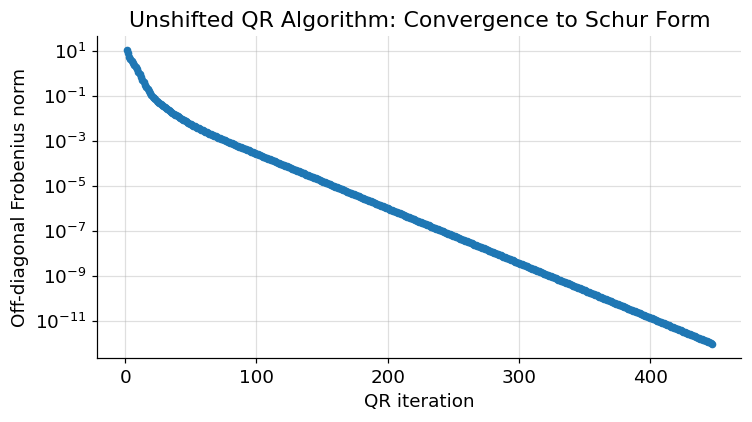

Eigenvalue evolution (snapshots):
  After   1 steps: max eigenvalue error = 5.2854e+00
  After  10 steps: max eigenvalue error = 1.9555e-01
  After  50 steps: max eigenvalue error = 5.7332e-05
  After 100 steps: max eigenvalue error = 2.1401e-07


In [10]:
# Convergence plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(hist_qr)+1), hist_qr, 'o-', ms=4, lw=1.5)
ax.set_xlabel('QR iteration')
ax.set_ylabel('Off-diagonal Frobenius norm')
ax.set_title('Unshifted QR Algorithm: Convergence to Schur Form')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Compare eigenvalues from diagonal of A^(k) with true eigenvalues
print("Eigenvalue evolution (snapshots):")
T_track = A_qr.copy().astype(float)
steps_shown = {1, 10, 50, 100}
for step in range(1, 101):
    Q_s, R_s = np.linalg.qr(T_track)
    T_track = R_s @ Q_s
    if step in steps_shown:
        diag = np.sort(np.diag(T_track))[::-1]
        err = np.max(np.abs(diag - eigs_true))
        print(f"  After {step:3d} steps: max eigenvalue error = {err:.4e}")


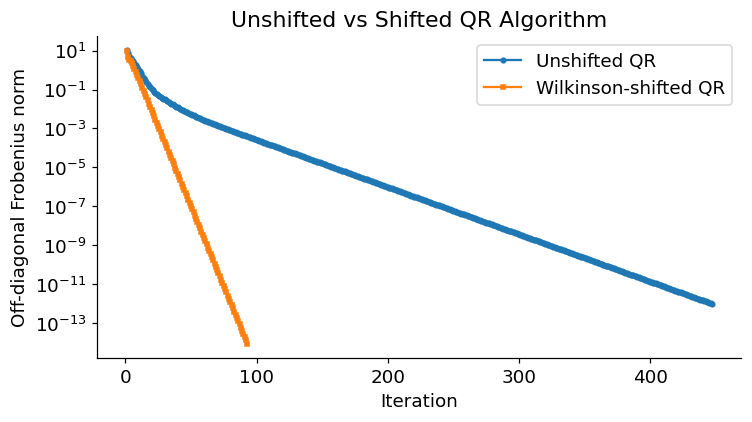

Unshifted QR: 447 iterations
Shifted QR:   93 iterations
Speedup from shift: 4.8x


In [11]:
# Shifted QR: Wilkinson shift for symmetric tridiagonal
def wilkinson_shift(T):
    'Compute the Wilkinson shift for a symmetric tridiagonal matrix T.'
    n = T.shape[0]
    a = T[n-1, n-1]
    b = T[n-2, n-1]  # = T[n-1, n-2]
    delta = (T[n-2, n-2] - a) / 2.0
    sign_d = np.sign(delta) if delta != 0 else 1.0
    return a - sign_d * b**2 / (abs(delta) + np.sqrt(delta**2 + b**2))

def shifted_qr_symmetric(A, max_iter=500, tol=1e-14):
    'Shifted QR for symmetric matrices with Wilkinson shift.'
    T_s = A.copy().astype(float)
    n = T_s.shape[0]
    history = []

    for _ in range(max_iter):
        mu_s = wilkinson_shift(T_s)
        Q_s, R_s = np.linalg.qr(T_s - mu_s * np.eye(n))
        T_s = R_s @ Q_s + mu_s * np.eye(n)
        off = np.sqrt(sum(T_s[i, j]**2 for i in range(n) for j in range(i)))
        history.append(off)
        if off < tol:
            break

    return T_s, history

T_shift, hist_shift = shifted_qr_symmetric(A_qr)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(hist_qr)+1), hist_qr, 'o-', ms=3, label='Unshifted QR')
ax.semilogy(range(1, len(hist_shift)+1), hist_shift, 's-', ms=3, label='Wilkinson-shifted QR')
ax.set_xlabel('Iteration')
ax.set_ylabel('Off-diagonal Frobenius norm')
ax.set_title('Unshifted vs Shifted QR Algorithm')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Unshifted QR: {len(hist_qr)} iterations")
print(f"Shifted QR:   {len(hist_shift)} iterations")
print(f"Speedup from shift: {len(hist_qr) / max(1, len(hist_shift)):.1f}x")


---
## 5. Other Algorithms and Connection to SVD

### Power Iteration

Power iteration computes the **dominant eigenpair** ($\lambda_1$, $q_1$) with $|\lambda_1| > |\lambda_2|$:

$$x_{k+1} = \frac{Ax_k}{\|Ax_k\|_2} \longrightarrow q_1.$$

Convergence rate: $|\lambda_2 / \lambda_1|^k$ per iteration.
If the ratio $|\lambda_2/\lambda_1|$ is close to 1, convergence is slow.

### Inverse Iteration

Apply power iteration to $(A - \mu I)^{-1}$ to find the eigenpair nearest $\mu$:

$$x_{k+1} = \frac{(A - \mu I)^{-1} x_k}{\|(A - \mu I)^{-1} x_k\|_2}.$$

Convergence rate: $|(\lambda_j - \mu)/(\lambda_k - \mu)|^k$ where $\lambda_k$ is the eigenvalue nearest $\mu$.
Combined with the Rayleigh quotient shift, convergence becomes cubic.

### Krylov Subspace Methods (Large Sparse Matrices)

For large, sparse matrices, forming the full Hessenberg or running dense QR is too expensive.
**Lanczos iteration** (symmetric) and **Arnoldi iteration** (general) build orthonormal bases for:

$$\mathcal{K}_k(A, b) = \operatorname{span}\{b, Ab, A^2 b, \ldots, A^{k-1}b\}.$$

These are the methods of choice for large sparse eigenvalue problems (e.g., in PDE discretizations).

### Connection to SVD

The singular values of $A$ relate to eigenvalues via:

$$\sigma_i(A) = \sqrt{\lambda_i(A^{\top}A)} = \sqrt{\lambda_i(AA^{\top})}.$$

Alternatively, the **augmented symmetric matrix**

$$C = \begin{pmatrix} 0 & A^{\top} \\ A & 0 \end{pmatrix}$$

is symmetric and has eigenvalues $\pm\sigma_i(A)$ and $0$ (with multiplicity $|m-n|$).
Applying symmetric eigenvalue algorithms to $C$ recovers the SVD.

**Why not use $A^{\top}A$ directly?**
Computing $A^{\top}A$ squares the condition number: $\kappa(A^{\top}A) = \kappa(A)^2$.
For a matrix with $\kappa(A) \approx 10^8$, this exhausts double precision.
The Golub-Reinsch algorithm first bidiagonalizes $A$ (which preserves singular values exactly) and
then applies QR to the bidiagonal matrix, maintaining $\kappa(A)$ rather than $\kappa(A)^2$.


Power iteration results:
  Computed dominant eigenvalue: 14.0801173414
  True dominant eigenvalue:     14.0801173414
  Convergence rate: |lambda_2/lambda_1| = 0.612517
  Converged in 32 iterations.


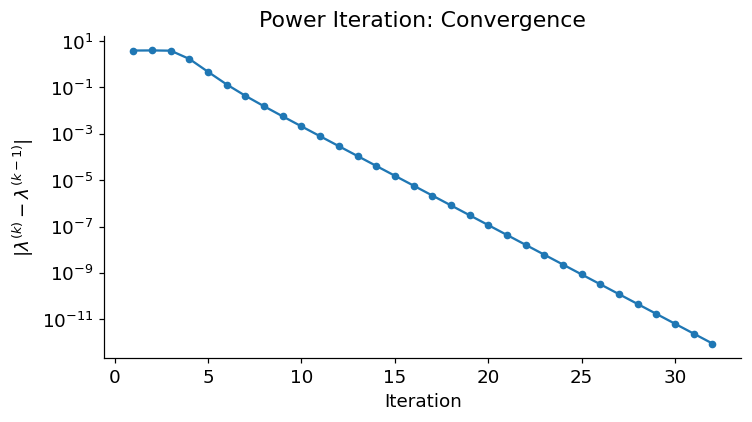

In [12]:
def power_iteration(A, max_iter=500, tol=1e-12):
    'Power iteration for dominant eigenpair.'
    n = A.shape[0]
    x = np.random.randn(n)
    x /= np.linalg.norm(x)
    eigval_prev = 0.0
    history = []

    for _ in range(max_iter):
        Ax = A @ x
        eigval = x @ Ax        # Rayleigh quotient
        history.append(abs(eigval - eigval_prev))
        x = Ax / np.linalg.norm(Ax)
        if abs(eigval - eigval_prev) < tol:
            break
        eigval_prev = eigval

    return eigval, x, history

np.random.seed(14)
n_pi = 6
B_pi = np.random.randn(n_pi, n_pi)
A_pi = B_pi.T @ B_pi + np.eye(n_pi)
eigvals_pi = np.linalg.eigvalsh(A_pi)

lam_dom, q_dom, hist_pi = power_iteration(A_pi)

print(f"Power iteration results:")
print(f"  Computed dominant eigenvalue: {lam_dom:.10f}")
print(f"  True dominant eigenvalue:     {eigvals_pi[-1]:.10f}")
print(f"  Convergence rate: |lambda_2/lambda_1| = {eigvals_pi[-2]/eigvals_pi[-1]:.6f}")
print(f"  Converged in {len(hist_pi)} iterations.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(hist_pi)+1), hist_pi, 'o-', ms=4)
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$|\lambda^{(k)} - \lambda^{(k-1)}|$')
ax.set_title('Power Iteration: Convergence')
plt.tight_layout()
plt.show()


Inverse iteration: targeting eigenvalue near 8.624315
  Computed eigenvalue: 8.6243153926
  True eigenvalue:     8.6243153926
  Converged in 8 iterations.


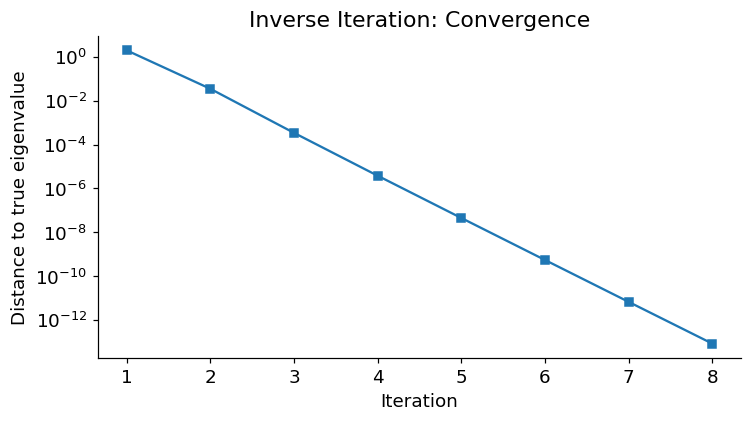

In [13]:
def inverse_iteration(A, mu, max_iter=50, tol=1e-12):
    'Inverse iteration with fixed shift mu. Finds eigenpair nearest mu.'
    n = A.shape[0]
    x = np.random.randn(n)
    x /= np.linalg.norm(x)
    M = A - mu * np.eye(n)
    # Pre-factorize M (LU) for efficiency
    lu_fac = la.lu_factor(M)
    history = []
    eigvals_true = np.linalg.eigvalsh(A)
    lam_nearest = eigvals_true[np.argmin(np.abs(eigvals_true - mu))]

    for _ in range(max_iter):
        y = la.lu_solve(lu_fac, x)
        x = y / np.linalg.norm(y)
        rq = x @ A @ x
        history.append(abs(rq - lam_nearest))
        if history[-1] < tol:
            break

    return x @ A @ x, x, history

# Target the second eigenvalue
mu_target = eigvals_pi[-2]
lam_inv, q_inv, hist_inv = inverse_iteration(A_pi, mu_target * 1.05)  # slightly off target

print(f"Inverse iteration: targeting eigenvalue near {mu_target:.6f}")
print(f"  Computed eigenvalue: {lam_inv:.10f}")
print(f"  True eigenvalue:     {mu_target:.10f}")
print(f"  Converged in {len(hist_inv)} iterations.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(1, len(hist_inv)+1), hist_inv, 's-', ms=5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Distance to true eigenvalue')
ax.set_title('Inverse Iteration: Convergence')
plt.tight_layout()
plt.show()


In [14]:
# SVD connection: eigenvalues of A^T A vs singular values of A
np.random.seed(20)
m_sv, n_sv = 8, 5
A_sv = np.random.randn(m_sv, n_sv)

# Method 1: eigenvalues of A^T A
ATA = A_sv.T @ A_sv
eigvals_ATA = np.linalg.eigvalsh(ATA)
sigma_from_eig = np.sqrt(np.maximum(eigvals_ATA, 0))[::-1]

# Method 2: direct SVD
_, sv_direct, _ = np.linalg.svd(A_sv)

print("Singular values via two routes:")
print(f"  sqrt(eig(A^T A)): {sigma_from_eig}")
print(f"  Direct SVD:       {sv_direct}")
print(f"  Max difference:   {np.max(np.abs(sigma_from_eig - sv_direct)):.2e}")

# Condition number squaring
kappa_A    = np.linalg.cond(A_sv)
kappa_ATA  = np.linalg.cond(ATA)
print(f"\nCondition number comparison:")
print(f"  kappa(A)     = {kappa_A:.6f}")
print(f"  kappa(A^T A) = {kappa_ATA:.6f}  (should be kappa(A)^2 = {kappa_A**2:.6f})")


Singular values via two routes:
  sqrt(eig(A^T A)): [4.90891973 3.46439204 3.05967548 2.32502152 1.06829812]
  Direct SVD:       [4.90891973 3.46439204 3.05967548 2.32502152 1.06829812]
  Max difference:   1.33e-15

Condition number comparison:
  kappa(A)     = 4.595084
  kappa(A^T A) = 21.114798  (should be kappa(A)^2 = 21.114798)


In [15]:
# SVD via augmented symmetric matrix C = [[0, A^T], [A, 0]]
m_au, n_au = 5, 3
A_au = np.random.randn(m_au, n_au)
zero_top = np.zeros((n_au, n_au))
zero_bot = np.zeros((m_au, m_au))

C = np.block([[zero_top, A_au.T],
              [A_au,     zero_bot]])

eigvals_C = np.linalg.eigvalsh(C)
print("Augmented symmetric matrix C = [[0, A^T],[A, 0]]:")
print(f"  Eigenvalues of C: {eigvals_C}")

sv_A = np.linalg.svd(A_au, compute_uv=False)
expected = sorted(list(-sv_A) + [0]*(m_au - n_au) + list(sv_A))
print(f"\n  Singular values of A:  {sv_A}")
print(f"  Expected C eigenvalues: {expected}")
print(f"\n  Eigenvalues of C are +/- sigma_i(A) and 0 (multiplicity |m-n| = {m_au-n_au})")
print(f"  Max residual: {np.max(np.abs(np.sort(eigvals_C) - np.array(expected))):.2e}")


Augmented symmetric matrix C = [[0, A^T],[A, 0]]:
  Eigenvalues of C: [-3.34627200e+00 -2.34469989e+00 -9.77515473e-01 -6.67340139e-19
  8.88845760e-16  9.77515473e-01  2.34469989e+00  3.34627200e+00]

  Singular values of A:  [3.346272   2.34469989 0.97751547]
  Expected C eigenvalues: [np.float64(-3.346272004470476), np.float64(-2.344699894710799), np.float64(-0.977515473106542), 0, 0, np.float64(0.977515473106542), np.float64(2.344699894710799), np.float64(3.346272004470476)]

  Eigenvalues of C are +/- sigma_i(A) and 0 (multiplicity |m-n| = 2)
  Max residual: 1.78e-15


---
## Final Summary: The Big Picture

The five notebooks trace a coherent path through the theory and computation of numerical linear algebra.

### The Role of Orthogonality

Every stable algorithm in this course reduces a problem via orthogonal transformations:
Householder for QR, Givens for Hessenberg reduction, unitary similarity in the Schur decomposition.
Orthogonal transformations preserve norms exactly, so they never amplify errors.

### The Role of Conditioning

Conditioning separates what is unavoidable (problem sensitivity) from what is controllable (algorithm stability).
A backward-stable algorithm on a well-conditioned problem always produces accurate results.
No algorithm, however clever, can compensate for an intrinsically ill-conditioned problem.

### Stable Factorizations

| Factorization | Best for | Cost | Key property |
|---|---|---|---|
| QR (Householder) | Least squares, orthonormal bases | $O(mn^2)$ | Backward stable |
| LU (partial pivot) | General $Ax = b$ | $O(n^3/3)$ | Backward stable in practice |
| Cholesky | SPD systems | $O(n^3/6)$ | Unconditionally stable |
| SVD | Rank, approximation, pseudoinverse | $O(mn^2)$ | Complete geometric information |

### Direct Methods, Least Squares, and Eigenvalues

These are not separate subjects:

- Least squares $\min\|Ax-b\|_2$ is solved by QR, which is also the foundation of the QR algorithm.
- The QR algorithm for eigenvalues applies QR factorization iteratively to a matrix.
- Singular values are square roots of eigenvalues of $A^{\top}A$; the SVD is diagonalization via two orthogonal matrices.
- Hessenberg reduction is a one-time preprocessing via Householder, identical in structure to QR factorization.

**Orthogonality, conditioning, and factorization are three facets of one subject.**
